# 📊 Diagnostic Evaluation Suite (Local & Kaggle Native)

Chào mừng bạn đến với Notebook đánh giá chuyên sâu cho hệ thống **Mamba Anomaly Detection Pipeline**.

Notebook này được thiết kế dựa trên logic cốt lõi của **`src/training/eval.py`** kết hợp với cách tải dữ liệu, tự động điều chỉnh tham số (auto-scaling) và hiển thị kết quả trực quan từ notebook huấn luyện.

### 🌟 Các Tính Năng Vượt Trội:
1. **Tự động cấu hình môi trường**: Tự động phát hiện nếu đang chạy trên **Kaggle** để cấu hình `sys.path` và các thư mục chứa dữ liệu đầu vào `/kaggle/input/datasets/sunbv21/dataset-bearings/`.
2. **Đánh giá đa mô hình (Multi-Model Evaluation)**: Hỗ trợ 6 mô hình cốt lõi: `LSTM`, `PatchLSTM`, `ModernTCN`, `PatchTST`, `Mamba-Hybrid`, và `MambaTS-Official`.
3. **Chống rò rỉ dữ liệu (Leakage-Free Calibration)**: Tính toán ngưỡng phát hiện bất thường (POT, Robust, 3-Sigma, GMM, Percentile, Optimal) hoàn toàn trên tập dữ liệu lành mạnh (`bearing_labels == 0`) trong khoảng `skip_ratio` đến `train_ratio`.
4. **Trực quan hóa Cao cấp**: So sánh hiệu năng qua sơ đồ 2x2 và vẽ luồng điểm bất thường (Anomaly Score Flow) cùng các ngưỡng động theo thời gian cho từng vòng bi.

---


In [1]:
# %%bash
# curl -L -o /content/dataset-bearings.zip \
#   https://www.kaggle.com/api/v1/datasets/download/sunbv21/dataset-bearings

In [2]:
# %%bash
# curl -L -o /content/mamba-sft-source.zip\
#   https://www.kaggle.com/api/v1/datasets/download/sunbv21/mamba-sft-source

In [3]:
# %%bash
# curl -L -o /content/models-pth.zip\
#   https://www.kaggle.com/api/v1/datasets/download/sunbv21/models-pth

In [4]:
# !unzip -q /content/mamba-sft-source.zip -d /content/

# !mkdir -p /content/data/processed
# !unzip -q /content/dataset-bearings.zip -d /content/data/processed

# !mkdir -p /content/results/models
# !unzip -q /content/models-pth.zip -d /content/results/models
# print("Đã giải nén xong!")

In [5]:
!pip install -q "nbconvert>=7.14.0" "ipywidgets>=8.1.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/261.9 kB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.9/261.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 4.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [6]:
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/216.4 kB ? eta -:--:--

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 5.9 MB/s eta 0:00:00


  Preparing metadata (pyproject.toml) ... done


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/43.5 MB ? eta -:--:--

   ━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/43.5 MB 85.5 MB/s eta 0:00:01

...

  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /root/.cache/pip/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83bcbc8ba7b41a2982992c63
Successfully built mamba-ssm


  Attempting uninstall: cuda-bindings


    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:


      Successfully uninstalled cuda-bindings-13.2.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [7]:
!python -c "import torch; import mamba_ssm; print('-> PyTorch nhận diện GPU:', torch.cuda.is_available()); print('-> Phiên bản Mamba-SSM:', mamba_ssm.__version__)"

-> PyTorch nhận diện GPU: True
-> Phiên bản Mamba-SSM: 2.3.2.post1


In [8]:
import os
from huggingface_hub import login

# Thay "YOUR_HF_TOKEN_HERE" bằng token thực tế của bạn hoặc thiết lập biến môi trường HF_TOKEN
hf_token = os.environ.get("HF_TOKEN", "YOUR_HF_TOKEN_HERE")

if hf_token and hf_token != "YOUR_HF_TOKEN_HERE":
    # Đăng nhập trực tiếp qua thư viện
    login(token=hf_token)
    # Hoặc thiết lập qua biến môi trường (Hugging Face tự động nhận diện)
    os.environ["HF_TOKEN"] = hf_token
else:
    print("Chưa cấu hình HF_TOKEN. Nếu dataset public thì không cần token.")

In [9]:
import os
import sys
from tqdm import tqdm

# 1. Phát hiện môi trường Kaggle
is_kaggle = os.path.exists('/kaggle')
print(f'Is running on Kaggle: {is_kaggle}')

train_bearings = ["B02", "B05", "B08", "B10", "B11", "B17"]
test_bearings = ["B01", "B03", "B04", "B08" , "B10", "B12", "B17"]
# train_bearings = ["B02"]
# test_bearings = ["B01", "B03"]
all_bearings = sorted(list(set(train_bearings + test_bearings)))

def sync_dataset(data_dir, bearings):
    """
    Hàm kiểm tra và đồng bộ dataset.
    Sử dụng snapshot_download để tự động so sánh hash của từng file:
    - Nếu file bị thiếu -> tự động tải.
    - Nếu file bị lỗi/không khớp hash -> tự động tải lại để fix.
    - Nếu file đã đủ và chuẩn -> tự động bỏ qua (rất nhanh).
    """
    os.makedirs(data_dir, exist_ok=True)
    print(f"-> Đang quét kiểm tra tính toàn vẹn và đồng bộ dữ liệu tại: {data_dir}...")
    try:
        from huggingface_hub import snapshot_download
        allow_patterns = [f"{b}/*" for b in bearings]
        snapshot_download(
            repo_id="hunglam015/Paderborn_Bearing_Run-to-Failure_Time-Varying",
            repo_type="dataset",
            revision="processed",
            local_dir=data_dir,
            allow_patterns=allow_patterns
        )
        print("-> Dữ liệu hoàn chỉnh và sẵn sàng!")
    except ImportError:
        print("⚠️ Cảnh báo: Thư viện huggingface_hub chưa được cài đặt. Hãy chạy: pip install huggingface_hub")
    except Exception as e:
        print(f"⚠️ Cảnh báo khi tải/kiểm tra dataset: {e}")

if is_kaggle:
    # Tự động định vị thư mục nguồn code trên Kaggle
    possible_source_roots = [
        '/kaggle/input/datasets/sunbv21/mamba-sft-source',
        '/kaggle/input/mamba-sft-source'
    ]
    kaggle_source_root = next((p for p in possible_source_roots if os.path.exists(p)), possible_source_roots[0])

    if kaggle_source_root not in sys.path:
        sys.path.append(kaggle_source_root)
    project_root = kaggle_source_root

    # Tự động định vị thư mục dữ liệu trên Kaggle
    possible_data_dirs = [
        '/kaggle/input/datasets/sunbv21/dataset-bearings',
        '/kaggle/input/dataset-bearings'
    ]
    kaggle_data_dir = next((p for p in possible_data_dirs if os.path.exists(p)), None)

    if kaggle_data_dir is None:
        # Nếu chưa có dataset gắn kèm, tải/kiểm tra trực tiếp từ Hugging Face vào /kaggle/working
        kaggle_data_dir = "/kaggle/working/data/processed"
        sync_dataset(kaggle_data_dir, all_bearings)
    else:
        # Dữ liệu từ Kaggle Input là Read-Only và được Kaggle đảm bảo tính toàn vẹn
        print(f"-> [Kaggle] Phát hiện dữ liệu được mount sẵn tại: {kaggle_data_dir}")

    train_dirs = [os.path.join(kaggle_data_dir, b) for b in train_bearings]
    test_dirs = [os.path.join(kaggle_data_dir, b) for b in test_bearings]

    # Thư mục checkpoints
    models_dir = "/kaggle/working/results/models"
    possible_model_dirs = [
        '/kaggle/input/datasets/sunbv21/models-pth',
        '/kaggle/input/models-pth'
    ]
    pretrained_models_dir = next((p for p in possible_model_dirs if os.path.exists(p)), possible_model_dirs[0])
    print(f'-> [Kaggle] project_root: {project_root}')
    print(f'-> [Kaggle] models_dir: {models_dir}')
    print(f'-> [Kaggle] train_dirs: {train_dirs}')
    print(f'-> [Kaggle] test_dirs: {test_dirs}')
else:
    # Cấu hình cục bộ
    project_root = os.path.abspath(".")
    # project_root = "/mnt/f/APPS_PJ/mamba-forecast-ad"
    if project_root not in sys.path:
        sys.path.append(project_root)

    data_dir = os.path.join(project_root, "data", "processed")

    # Tự động quét, tải file thiếu và sửa file lỗi cục bộ
    # sync_dataset(data_dir, all_bearings)

    train_dirs = [os.path.join(data_dir, b) for b in train_bearings]
    test_dirs = [os.path.join(data_dir, b) for b in test_bearings]
    models_dir = os.path.join(project_root, "results", "models")

    print(f'-> [Local] project_root: {project_root}')
    print(f'-> [Local] models_dir: {models_dir}')
    print(f'-> [Local] train_dirs: {train_dirs}')
    print(f'-> [Local] test_dirs: {test_dirs}')

Is running on Kaggle: True
-> [Kaggle] Phát hiện dữ liệu được mount sẵn tại: /kaggle/input/datasets/sunbv21/dataset-bearings
-> [Kaggle] project_root: /kaggle/input/datasets/sunbv21/mamba-sft-source
-> [Kaggle] models_dir: /kaggle/working/results/models
-> [Kaggle] train_dirs: ['/kaggle/input/datasets/sunbv21/dataset-bearings/B02', '/kaggle/input/datasets/sunbv21/dataset-bearings/B05', '/kaggle/input/datasets/sunbv21/dataset-bearings/B08', '/kaggle/input/datasets/sunbv21/dataset-bearings/B10', '/kaggle/input/datasets/sunbv21/dataset-bearings/B11', '/kaggle/input/datasets/sunbv21/dataset-bearings/B17']
-> [Kaggle] test_dirs: ['/kaggle/input/datasets/sunbv21/dataset-bearings/B01', '/kaggle/input/datasets/sunbv21/dataset-bearings/B03', '/kaggle/input/datasets/sunbv21/dataset-bearings/B04', '/kaggle/input/datasets/sunbv21/dataset-bearings/B08', '/kaggle/input/datasets/sunbv21/dataset-bearings/B10', '/kaggle/input/datasets/sunbv21/dataset-bearings/B12', '/kaggle/input/datasets/sunbv21/datas

In [10]:
import time
import yaml
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc as auc_score_func
from huggingface_hub import HfApi, login

from src.data import MultiBearingDataset
from src.models.mamba import HybridMambaCNN, MambaTSOfficial, MambaTSConfig, SimpleMamba
from src.models.baselines.lstm import LSTMForecaster
from src.models.baselines.modern_tcn import ModernTCNForecaster
from src.models.baselines.patch_models import PatchTST
from src.models.baselines.patch_models import PatchLSTM
from src.evaluation.anomaly_scorer import calculate_anomaly_score
from src.evaluation.metrics import (
    calculate_threshold_3sigma, calculate_threshold_robust,
    calculate_threshold_percentile, calculate_threshold_gmm,
    find_best_threshold, calculate_metrics, calculate_threshold_pot
)
import mamba_ssm.modules.mamba_simple
import mamba_ssm.ops.selective_scan_interface
mamba_ssm.modules.mamba_simple.causal_conv1d_fn = None
mamba_ssm.ops.selective_scan_interface.causal_conv1d_fn = None
torch.backends.cudnn.enabled = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


In [11]:
# =====================================================================
# SEED CO DINH - REPRODUCIBILITY
# Dat seed co dinh de dam bao ket qua thi nghiem co the tai tao hoan toan.
# =====================================================================
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print(f"[SEED] Global seed: {SEED}")

[SEED] Global seed: 42


In [12]:
config_path = os.path.join(project_root, 'configs/nano.yaml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("--- Cấu hình Config ---")
print(yaml.dump(config, default_flow_style=False))


--- Cấu hình Config ---
data:
  highpass_freq: 2000
  horizon: 16
  label_strategy: manual
  lookback: 128
  manual_fault_start:
    B01: 212
    B02: 867
    B03: 554
    B04: 463
    B05: 554
    B08: 1213
    B10: 2708
    B11: 716
    B12: 60
    B17: 2187
  processed_dir: data/processed/B17
  raw_dir: data/raw/B17
  sampling_rate: 128000
  skip_ratio: 0.05
  test_datasets:
  - data/processed/B02
  - data/processed/B03
  - data/processed/B04
  - data/processed/B05
  train_datasets:
  - data/processed/B02
  - data/processed/B05
  train_ratio: 0.4
  window_stride: 1024
logging:
  project_name: Hybrid_Mamba_CNN_Nano
  use_wandb: false
model:
  auto_scale_baselines: true
  bidirectional: false
  cnn_out_channels: 64
  decomp_alpha: 0.1
  decomp_learnable: true
  mamba_d_conv: 3
  mamba_d_model: 64
  mamba_d_state: 16
  mamba_expand: 3
  mamba_n_layer: 4
  patch_size: 16
  patch_stride: 8
  trend_downsample: 16
training:
  batch_size: 256
  device: cuda
  epochs: 10
  learning_rate: 5e-

In [13]:
# 3. Tải dữ liệu bằng MultiBearingDataset
window_stride = config['data'].get('window_stride', 2048)
# lookback = config['data'].get('lookback', 16384)
# horizon = config['data'].get('horizon', 1024)
lookback = 4096
horizon = 512
sampling_rate = config['data'].get('sampling_rate', 128000)
highpass_freq = 0
# highpass_freq = config['data'].get('highpass_freq', 2000)
train_ratio = config['data'].get('train_ratio', 0.5)
skip_ratio = config['data'].get('skip_ratio', 0.1)
label_strategy = config['data'].get('label_strategy', 'rms')
batch_size = 1024
# batch_size = config['training'].get('batch_size', 256)

print('Loading train datasets...')
train_dataset = MultiBearingDataset(
    train_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='train',
    file_sample_ratio=1, train_ratio=train_ratio, skip_ratio=skip_ratio,
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate, label_strategy=label_strategy
)
oc_stats = train_dataset.oc_stats

print('Loading val datasets...')
val_dataset = MultiBearingDataset(
    train_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='val',
    file_sample_ratio=1, oc_stats=oc_stats, train_ratio=train_ratio, skip_ratio=skip_ratio,
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate, label_strategy=label_strategy
)

manual_fault_start = {
    "B01": "data_B01_M0208.pt",
    "B03": "data_B03_M0547.pt",
    "B04": "data_B04_M0444.pt",
    "B08": "data_B08_M01214.pt",
    "B10": "data_B10_M02672.pt",
    "B12": "data_B12_M00436.pt",
    "B17": "data_B17_M02189.pt",
}

print('Loading testing datasets...')
test_dataset = MultiBearingDataset(
    test_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='test',
    file_sample_ratio=1, oc_stats=oc_stats, train_ratio=train_ratio, skip_ratio=skip_ratio,
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate,
    label_strategy='manual', manual_fault_start=manual_fault_start
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print('\n--- Dữ liệu tải thành công ---')
print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Loading train datasets...


Loading val datasets...


Loading testing datasets...



--- Dữ liệu tải thành công ---
Train samples: 290148
Val samples: 144832
Test samples: 1416176


In [14]:
import os
import time
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_curve, auc as auc_score_func
from tqdm import tqdm

# 5. Định nghĩa Hàm Đánh giá evaluate_variant (Per-Bearing & Leakage-Free) với Đo lường Độ trễ Chi tiết
def evaluate_variant(variant_name, model, val_loader, test_loader, device):
    model.eval()

    macro_metrics = {
        t_name: {"F1": [], "FAR": [], "AUC": [], "AUPRC": []}
        for t_name in ["3-Sigma", "Robust", "Percentile", "POT", "Self-Learn", "Optimal"]
    }

    macro_forecasting = {
        "MAE": [], "MSE": [], "RMSE": [], "MAPE": []
    }

    # Khởi tạo các danh sách đo độ trễ chi tiết
    transfer_latencies = []
    inf_latencies = []
    scoring_latencies = []
    decision_latencies = []
    total_eval_latencies = []

    calib_times = {
        "3-Sigma": [],
        "Robust": [],
        "Percentile": [],
        "POT": [],
        "Self-Learn": [],
        "Optimal": []
    }

    val_forecasting = {
        "MAE": [], "MSE": [], "RMSE": [], "MAPE": []
    }

    val_datasets = val_loader.dataset.datasets if hasattr(val_loader.dataset, "datasets") else [val_loader.dataset]
    for val_idx, ds in enumerate(val_datasets):
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
        bearing_mae_list = []
        bearing_mse_list = []
        bearing_mape_list = []
        with torch.no_grad():
            # Thêm tqdm cho vòng lặp Validation
            for batch in tqdm(loader, desc=f"Val Dataset {val_idx+1}/{len(val_datasets)}", leave=False):
                x = batch[0].to(device)
                y = batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    if stats is not None and isinstance(model, HybridMambaCNN) and model.use_stats:
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)
                y_cpu = y.cpu().numpy()
                y_pred_cpu = y_pred.cpu().numpy()
                batch_mae = np.mean(np.abs(y_cpu - y_pred_cpu))
                batch_mse = np.mean((y_cpu - y_pred_cpu) ** 2)
                epsilon = 1e-5
                batch_mape = np.mean(np.abs(y_cpu - y_pred_cpu) / (np.abs(y_cpu) + epsilon)) * 100
                bearing_mae_list.append(batch_mae)
                bearing_mse_list.append(batch_mse)
                bearing_mape_list.append(batch_mape)
        val_forecasting["MAE"].append(np.mean(bearing_mae_list))
        val_forecasting["MSE"].append(np.mean(bearing_mse_list))
        val_forecasting["RMSE"].append(np.sqrt(np.mean(bearing_mse_list)))
        val_forecasting["MAPE"].append(np.mean(bearing_mape_list))

    test_datasets = test_loader.dataset.datasets if hasattr(test_loader.dataset, 'datasets') else [test_loader.dataset]

    # Khởi động lại theo dõi peak VRAM cho phase evaluate
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    for test_idx, ds in enumerate(test_datasets):
        bearing_name = os.path.basename(ds.data_dir) if hasattr(ds, 'data_dir') else f"Bearing_{test_idx}"
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

        bearing_scores = []
        bearing_rms = []
        bearing_kurt = []
        bearing_labels = []
        bearing_mae_list = []
        bearing_mse_list = []
        bearing_mape_list = []

        with torch.no_grad():
            # Thêm tqdm cho vòng lặp Test
            for batch in tqdm(loader, desc=f"Test Dataset: {bearing_name}", leave=False):
                # 1. Đo lường thời gian truyền dữ liệu (CPU -> GPU)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t0 = time.time()

                x = batch[0].to(device)
                y = batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None

                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t1 = time.time()

                # 2. Đo lường thời gian Model Inference (Forward Pass) với Autocast
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    if stats is not None and isinstance(model, HybridMambaCNN) and model.use_stats:
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)

                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t2 = time.time()

                # 3. Đo lường thời gian Tính điểm bất thường (Anomaly Scoring)
                scores = calculate_anomaly_score(y, y_pred, metric='mse', normalized=False)

                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t3 = time.time()

                # 4. Đo lường thời gian Ra quyết định (Threshold Decision)
                dummy_threshold = 0.5
                is_anomaly = scores > dummy_threshold

                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t4 = time.time()

                # Lưu trữ kết quả đo lường độ trễ trên mỗi sample (ms/sample)
                n_samples = x.size(0)
                transfer_ms = (t1 - t0) * 1000 / n_samples
                inf_ms = (t2 - t1) * 1000 / n_samples
                score_ms = (t3 - t2) * 1000 / n_samples
                decision_ms = (t4 - t3) * 1000 / n_samples
                total_ms = (t4 - t0) * 1000 / n_samples

                transfer_latencies.append(transfer_ms)
                inf_latencies.append(inf_ms)
                scoring_latencies.append(score_ms)
                decision_latencies.append(decision_ms)
                total_eval_latencies.append(total_ms)

                bearing_scores.extend(scores.tolist())

                if stats is not None:
                    # stats has shape [batch_size, channels, 8]
                    # rms is index 2, kurtosis is index 5
                    rms_sample = stats[:, :, 2].mean(dim=-1).cpu().numpy().tolist()
                    kurt_sample = stats[:, :, 5].mean(dim=-1).cpu().numpy().tolist()
                    bearing_rms.extend(rms_sample)
                    bearing_kurt.extend(kurt_sample)
                else:
                    bearing_rms.extend([0.0] * x.size(0))
                    bearing_kurt.extend([3.0] * x.size(0))

                if len(batch) > 3:
                    bearing_labels.extend(batch[3].cpu().numpy().tolist())
                else:
                    bearing_labels.extend([0] * x.size(0))

                y_cpu = y.cpu().numpy()
                y_pred_cpu = y_pred.cpu().numpy()

                batch_mae = np.mean(np.abs(y_cpu - y_pred_cpu))
                batch_mse = np.mean((y_cpu - y_pred_cpu) ** 2)
                epsilon = 1e-5
                batch_mape = np.mean(np.abs(y_cpu - y_pred_cpu) / (np.abs(y_cpu) + epsilon)) * 100

                bearing_mae_list.append(batch_mae)
                bearing_mse_list.append(batch_mse)
                bearing_mape_list.append(batch_mape)

        bearing_scores = np.array(bearing_scores)
        bearing_labels = np.array(bearing_labels, dtype=int)

        n_total = len(bearing_labels)

        bearing_mae = np.mean(bearing_mae_list)
        bearing_mse = np.mean(bearing_mse_list)
        bearing_rmse = np.sqrt(bearing_mse)
        bearing_mape = np.mean(bearing_mape_list)

        macro_forecasting["MAE"].append(bearing_mae)
        macro_forecasting["MSE"].append(bearing_mse)
        macro_forecasting["RMSE"].append(bearing_rmse)
        macro_forecasting["MAPE"].append(bearing_mape)

        # Thiết lập khoảng dữ liệu healthy tính ngưỡng
        skip_end = int(n_total * skip_ratio)
        train_end = int(n_total * (skip_ratio + train_ratio))

        normal_indices = np.where(bearing_labels == 0)[0]
        if len(normal_indices) > 0:
            train_end = min(train_end, normal_indices[-1] + 1)

        if train_end > skip_end:
            healthy_subset = bearing_scores[skip_end:train_end]
            healthy_labels = bearing_labels[skip_end:train_end]
            healthy_scores = healthy_subset[healthy_labels == 0]
            if len(healthy_scores) == 0:
                healthy_scores = bearing_scores[:max(1, int(n_total * 0.1))]
        else:
            healthy_scores = bearing_scores[:max(1, int(n_total * 0.1))]

        # Đo lường thời gian hiệu chuẩn từng thuật toán ngưỡng
        t_cal = time.time()
        local_th_3s  = calculate_threshold_3sigma(healthy_scores)
        calib_times["3-Sigma"].append((time.time() - t_cal) * 1000)

        t_cal = time.time()
        local_th_rb  = calculate_threshold_robust(healthy_scores)
        calib_times["Robust"].append((time.time() - t_cal) * 1000)

        t_cal = time.time()
        local_th_pc  = calculate_threshold_percentile(healthy_scores, q=99.7)
        calib_times["Percentile"].append((time.time() - t_cal) * 1000)

        t_cal = time.time()
        local_th_pot = calculate_threshold_pot(healthy_scores, q=1e-3)
        calib_times["POT"].append((time.time() - t_cal) * 1000)

        t_cal = time.time()
        local_th_gmm = calculate_threshold_gmm(bearing_scores)
        calib_times["Self-Learn"].append((time.time() - t_cal) * 1000)

        t_cal = time.time()
        local_th_opt, _ = find_best_threshold(bearing_scores, bearing_labels)
        calib_times["Optimal"].append((time.time() - t_cal) * 1000)

        if len(np.unique(bearing_labels)) > 1:
            precision_path, recall_path, _ = precision_recall_curve(bearing_labels, bearing_scores)
            bearing_auprc = auc_score_func(recall_path, precision_path)
        else:
            bearing_auprc = 0.0

        thresholds = [
            ("3-Sigma", local_th_3s), ("Robust", local_th_rb), ("Percentile", local_th_pc),
            ("POT", local_th_pot), ("Self-Learn", local_th_gmm), ("Optimal", local_th_opt)
        ]

        for t_name, t_val in thresholds:
            m = calculate_metrics(bearing_scores, bearing_labels, t_val)
            macro_metrics[t_name]["F1"].append(m.get('F1', 0))
            macro_metrics[t_name]["FAR"].append(m.get('FAR', 0))
            macro_metrics[t_name]["AUC"].append(m.get('AUC', 0))
            macro_metrics[t_name]["AUPRC"].append(bearing_auprc)

        # Tích hợp lưu trữ kết quả để so sánh 2x2 ở mức sample (chi tiết hơn)
        if 'comparison_results' not in globals():
            globals()['comparison_results'] = {}
        global_comp = globals()['comparison_results']
        if bearing_name not in global_comp:
            global_comp[bearing_name] = {}

        global_comp[bearing_name][variant_name] = {
            'mse': bearing_scores,
            'file_indices': [ds.samples[i][0] for i in range(len(bearing_scores))],
            'indices': [ds.samples[i][0] for i in range(len(bearing_scores))],
            'files': ds.files,
            'rms': bearing_rms,
            'kurtosis': bearing_kurt
        }

        last_bearing_data = {
            'bearing_name': bearing_name,
            'scores': bearing_scores,
            'labels': bearing_labels,
            'th_3sigma': local_th_3s,
            'th_robust': local_th_rb,
            'th_pot': local_th_pot
        }

    # Lấy Peak VRAM cho evaluation
    peak_vram = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0

    avg_transfer_lat = float(np.mean(transfer_latencies))
    avg_inf_lat = float(np.mean(inf_latencies))
    avg_scoring_lat = float(np.mean(scoring_latencies))
    avg_decision_lat = float(np.mean(decision_latencies))
    avg_total_eval_lat = float(np.mean(total_eval_latencies))
    avg_calib_times = {k: float(np.mean(v)) for k, v in calib_times.items()}

    avg_mae = float(np.mean(macro_forecasting["MAE"]))
    avg_mse = float(np.mean(macro_forecasting["MSE"]))
    avg_rmse = float(np.mean(macro_forecasting["RMSE"]))
    avg_mape = float(np.mean(macro_forecasting["MAPE"]))

    avg_val_mae = float(np.mean(val_forecasting["MAE"]))
    avg_val_mse = float(np.mean(val_forecasting["MSE"]))
    avg_val_rmse = float(np.mean(val_forecasting["RMSE"]))
    avg_val_mape = float(np.mean(val_forecasting["MAPE"]))

    print(f"\n============================================================")
    print(f">>> MACRO-AVERAGE PERFORMANCE - VARIANT: {variant_name}")
    print(f"   [Val Forecast]  > MAE: {avg_val_mae:.6f} | MSE: {avg_val_mse:.6f} | RMSE: {avg_val_rmse:.6f} | MAPE: {avg_val_mape:.4f}%")
    print(f"   [Test Forecast] > MAE: {avg_mae:.6f} | MSE: {avg_mse:.6f} | RMSE: {avg_rmse:.6f} | MAPE: {avg_mape:.4f}%")
    print(f"   [Resource]    > Peak VRAM: {peak_vram:.2f} MB")
    print(f"   [Latency Breakdown (per sample)]:")
    print(f"     * Data Transfer:  {avg_transfer_lat:.4f} ms")
    print(f"     * Model Inference: {avg_inf_lat:.4f} ms")
    print(f"     * Anomaly Scoring: {avg_scoring_lat:.4f} ms")
    print(f"     * Decision:        {avg_decision_lat:.4f} ms")
    print(f"     * TOTAL LATENCY:   {avg_total_eval_lat:.4f} ms/sample")
    print(f"============================================================")

    res_dict = {
        "Val MAE": avg_val_mae,
        "Val MSE": avg_val_mse,
        "Val RMSE": avg_val_rmse,
        "Val MAPE": avg_val_mape,
        "Test MAE": avg_mae,
        "Test MSE": avg_mse,
        "Test RMSE": avg_rmse,
        "Test MAPE": avg_mape,
        "VRAM Inference (MB)": peak_vram,
        "Latency (ms)": avg_total_eval_lat,
        "Lat Transfer (ms)": avg_transfer_lat,
        "Lat Inference (ms)": avg_inf_lat,
        "Lat Scoring (ms)": avg_scoring_lat,
        "Lat Decision (ms)": avg_decision_lat,
    }

    for t_name in ["3-Sigma", "Robust", "Percentile", "POT", "Self-Learn", "Optimal"]:
        res_dict[f"F1 ({t_name})"] = np.mean(macro_metrics[t_name]["F1"])
        res_dict[f"FAR ({t_name})"] = np.mean(macro_metrics[t_name]["FAR"])
        res_dict[f"AUC ({t_name})"] = np.mean(macro_metrics[t_name]["AUC"])
        res_dict[f"AUPRC ({t_name})"] = np.mean(macro_metrics[t_name]["AUPRC"])
        res_dict[f"Calib Time {t_name} (ms)"] = avg_calib_times[t_name]

    # Compatibility keys for downstream analysis and plotting cells
    res_dict['name'] = variant_name
    res_dict['f1_3s'] = res_dict.get('F1 (3-Sigma)', 0.0)
    res_dict['f1_rb'] = res_dict.get('F1 (Robust)', 0.0)
    res_dict['f1_pot'] = res_dict.get('F1 (POT)', 0.0)
    res_dict['auc'] = res_dict.get('AUC (POT)', 0.0)
    res_dict['far_pot'] = res_dict.get('FAR (POT)', 0.0)
    res_dict['auprc'] = res_dict.get('AUPRC (POT)', 0.0)
    res_dict['latency'] = res_dict.get('Latency (ms)', 0.0)
    res_dict['mae'] = res_dict.get('Test MAE', 0.0)
    res_dict['mse'] = res_dict.get('Test MSE', 0.0)
    res_dict['rmse'] = res_dict.get('Test RMSE', 0.0)
    res_dict['mape'] = res_dict.get('Test MAPE', 0.0)
    res_dict['peak_vram_mb'] = res_dict.get('VRAM Inference (MB)', 0.0)
    res_dict['last_bearing'] = last_bearing_data
    res_dict['latency_breakdown'] = {
        'data_transfer': avg_transfer_lat,
        'inference': avg_inf_lat,
        'scoring': avg_scoring_lat,
        'decision': avg_decision_lat,
        'total': avg_total_eval_lat
    }
    res_dict['calib_latencies'] = avg_calib_times

    return res_dict

## 3.5. Định nghĩa Early Stopping
Lớp hỗ trợ dừng sớm khi tổn thất (loss) trên tập Validation không giảm sau một số epoch liên tiếp.

In [15]:
class EarlyStopping:
    def __init__(self, patience=3, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

        # Khởi tạo API của Hugging Face
        self.api = HfApi()

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')

        # 1. Lưu trọng số mô hình xuống máy ảo local
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

        # 2. Upload file vừa lưu lên Hugging Face
        if self.verbose:
            print(f"Đang upload {self.path} lên Hugging Face...")

        self.api.upload_file(
            path_or_fileobj=self.path,              # Lấy trực tiếp file vừa lưu từ self.path
            path_in_repo=self.path,                 # Tên file trên repo sẽ hiển thị giống tên local
            repo_id="sunbv56/mamba_baselines",      # Repo đích của bạn
            repo_type="model"                       # Loại repo là model
        )

        if self.verbose:
            print(f"Đã upload {self.path} lên Hugging Face thành công!")

## 3.6. Định nghĩa Hàm Huấn luyện Mô hình
Hàm huấn luyện các mô hình baselines và Mamba với Huber Loss và cơ chế dừng sớm (Early Stopping) trên tập Validation.

In [16]:
def train_one_model_in_notebook(name, model, train_loader, val_loader, config, device, config_name='nano', save_dir=None):
    if save_dir is None:
        save_dir = globals().get('models_dir', 'results/models')
    os.makedirs(save_dir, exist_ok=True)

    print(f'\n>>> Huấn luyện {name} (Cấu hình: {config_name})...')

    # Khởi tạo lại thống kê bộ nhớ đỉnh nếu dùng GPU
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats(device)

    model.to(device)

    lr = float(config['training'].get('learning_rate', 5e-4))

    # Bản đồ tên checkpoint để tìm và load checkpoint hiện có trước khi huấn luyện
    model_slug = name.lower().replace('-', '_')
    checkpoint_file = f'{model_slug}_{config_name}_best.pth'

    checkpoint_path = None
    search_dirs = []
    if save_dir:
        search_dirs.append(save_dir)
    search_dirs.append(globals().get('models_dir', 'results/models'))
    if 'pretrained_models_dir' in globals():
        search_dirs.append(globals()['pretrained_models_dir'])

    for d in search_dirs:
        p = os.path.join(d, checkpoint_file)
        if os.path.exists(p):
            checkpoint_path = p
            break

    start_epoch = 1
    total_epochs = 10

    if checkpoint_path is not None:
        print(f"Loading checkpoint weights from {checkpoint_path}...")
        try:
            model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
            print("Checkpoint loaded successfully. Resuming training from epoch 7 to 10.")
            start_epoch = 7
            total_epochs = 10
        except Exception as e:
            print(f"Error loading checkpoint {checkpoint_path}: {e}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.HuberLoss(delta=1.0)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=lr * 1e-2)
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

    # Tua nhanh scheduler nếu huấn luyện tiếp từ checkpoint
    for _ in range(start_epoch - 1):
        scheduler.step()

    best_model_path = os.path.join(save_dir, f'{model_slug}_{config_name}_best.pth')
    early_stopping = EarlyStopping(patience=3, verbose=True, path=best_model_path)

    # Thiết lập loss validation cơ sở cho early stopping nếu tải checkpoint
    if start_epoch > 1:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch[0].to(device), batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None

                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    if stats is not None and isinstance(model, HybridMambaCNN):
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)
                    loss = criterion(y_pred, y)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        print(f"Baseline Validation Loss from checkpoint: {avg_val_loss:.6f}")
        early_stopping.val_loss_min = avg_val_loss
        early_stopping.best_score = -avg_val_loss

    losses = []
    start_train = time.time()

    for epoch in range(start_epoch, total_epochs + 1):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f'{name} - Epoch {epoch}/{total_epochs}', mininterval=5.0)
        for batch in pbar:
            x, y = batch[0].to(device), batch[1].to(device)
            stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None

            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                if stats is not None and isinstance(model, HybridMambaCNN):
                    y_pred = model(x, stats)
                else:
                    y_pred = model(x)
                loss = criterion(y_pred, y)

            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()

            # Cập nhật thông số hiển thị trên tqdm (thêm VRAM thực tế)
            postfix = {'loss': f'{loss.item():.4f}'}
            if device.type == 'cuda':
                vram_active = torch.cuda.memory_allocated(device) / (1024 ** 2)
                postfix['vram_mb'] = f'{vram_active:.0f}'
            pbar.set_postfix(postfix)

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)

        # Báo cáo VRAM sau khi huấn luyện trong epoch
        if device.type == 'cuda':
            vram_alloc = torch.cuda.memory_allocated(device) / (1024 ** 2)
            vram_reserved = torch.cuda.memory_reserved(device) / (1024 ** 2)
            print(f'Epoch [{epoch}/{total_epochs}] - Train Loss: {avg_loss:.6f} | VRAM: {vram_alloc:.0f}/{vram_reserved:.0f} MB')
        else:
            print(f'Epoch [{epoch}/{total_epochs}] - Train Loss: {avg_loss:.6f}')

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch[0].to(device), batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None

                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    if stats is not None and isinstance(model, HybridMambaCNN):
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)
                    loss = criterion(y_pred, y)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        current_lr = scheduler.get_last_lr()[0]

        # Báo cáo VRAM sau bước Validation
        if device.type == 'cuda':
            vram_alloc = torch.cuda.memory_allocated(device) / (1024 ** 2)
            vram_reserved = torch.cuda.memory_reserved(device) / (1024 ** 2)
            print(f'Epoch [{epoch}/{total_epochs}] - Val Loss: {avg_val_loss:.6f} | LR: {current_lr:.2e} | VRAM: {vram_alloc:.0f}/{vram_reserved:.0f} MB')
        else:
            print(f'Epoch [{epoch}/{total_epochs}] - Val Loss: {avg_val_loss:.6f} | LR: {current_lr:.2e}')

        scheduler.step()
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print('Early stopping kích hoạt!')
            break

    train_duration = time.time() - start_train

    # Hiển thị lượng VRAM đỉnh (Peak VRAM) tiêu thụ suốt quá trình train
    if device.type == 'cuda':
        peak_vram = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
        print(f'Huấn luyện tốn {train_duration:.2f} giây | Peak GPU VRAM: {peak_vram:.0f} MB')
    else:
        print(f'Huấn luyện tốn {train_duration:.2f} giây')

    # Tải lại trọng số tốt nhất
    print(f'Loading best model weights from {best_model_path}...')
    model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))

    # Tính Peak VRAM để đưa vào kết quả trả về
    peak_vram_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if device.type == 'cuda' else 0

    # Giải phóng bộ nhớ
    optimizer.zero_grad(set_to_none=True)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        'name': name,
        'losses': losses,
        'train_duration': train_duration,
        'best_model_path': best_model_path,
        'peak_vram_mb': peak_vram_mb,
        'epochs_trained': total_epochs - start_epoch + 1
    }

In [17]:
# 6. Khởi tạo Mô hình & Tải Trọng số Checkpoints (Dynamic & Auto-Scaled)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def find_closest_lstm(target, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for h in range(8, 1024, 2):
        model = LSTMForecaster(input_dim=2, hidden_dim=h, num_layers=3, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = h
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params

def find_closest_patch_lstm(target, patch_size, stride, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 2):
        model = PatchLSTM(in_channels=2, patch_size=patch_size, stride=stride, d_model=d, num_layers=3, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params

def find_closest_modern_tcn(target, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 2):
        model = ModernTCNForecaster(input_dim=2, d_model=d, num_layers=3, kernel_size=17, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params

def find_closest_patchtst(target, lookback, patch_size, stride, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 4):
        nhead = 4 if d >= 4 else 1
        if d % 4 != 0:
            nhead = 2 if d % 2 == 0 else 1
        model = PatchTST(in_channels=2, lookback=lookback, patch_size=patch_size, stride=stride, d_model=d, nhead=nhead, num_layers=3, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params


def find_closest_simple_mamba(target, lookback, horizon, mamba_n_layer=4, mamba_d_state=16, mamba_d_conv=4, mamba_expand=2, mamba_version=1):
    from src.models.mamba import SimpleMamba
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 2):
        model = SimpleMamba({
            'model': {
                'mamba_version': mamba_version,
                'mamba_d_model': d,
                'mamba_n_layer': mamba_n_layer,
                'mamba_d_state': mamba_d_state,
                'mamba_d_conv': mamba_d_conv,
                'mamba_expand': mamba_expand,
                'forecast_len': horizon,
                'in_channels': 2,
                'lookback': lookback,
            },
            'data': {'lookback': lookback}
        })
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params


# Lấy các tham số cấu hình model từ config
patch_size = config.get('model', {}).get('patch_size', 16)
patch_stride = config.get('model', {}).get('patch_stride', 8)
trend_downsample = config.get('model', {}).get('trend_downsample', 1)

# 1. Khởi tạo Mamba1-Hybrid
mamba_model = HybridMambaCNN({
    'model': {
        'mamba_version': 1,
        'mamba_d_model': config.get('model', {}).get('mamba_d_model', 64),
        'mamba_n_layer': config.get('model', {}).get('mamba_n_layer', 4),
        'mamba_d_state': config.get('model', {}).get('mamba_d_state', 16),
        'mamba_d_conv': config.get('model', {}).get('mamba_d_conv', 4),
        'mamba_expand': config.get('model', {}).get('mamba_expand', 2),
        'forecast_len': horizon,
        'patch_size': patch_size,
        'stride': patch_stride,
        'trend_downsample': trend_downsample,
        'in_channels': 2, 'lookback': lookback,
        'decomp_alpha': config.get('model', {}).get('decomp_alpha', 0.1),
        'decomp_learnable': config.get('model', {}).get('decomp_learnable', True),
        'use_multiscale': False,
        'use_revin': False,
        'use_decomposition': True,
        'use_stats': True,
    },
    'data': {
        'patch_size': patch_size,
        'stride': patch_stride,
        'lookback': lookback
    }
})


# 1.5. Khởi tạo Simple-Mamba (Point-wise version, no patching)
simple_mamba = SimpleMamba({
    'model': {
        'mamba_version': 1,
        'mamba_d_model': config.get('model', {}).get('mamba_d_model', 64),
        'mamba_n_layer': config.get('model', {}).get('mamba_n_layer', 4),
        'mamba_d_state': config.get('model', {}).get('mamba_d_state', 16),
        'mamba_d_conv': config.get('model', {}).get('mamba_d_conv', 4),
        'mamba_expand': config.get('model', {}).get('mamba_expand', 2),
        'forecast_len': horizon,
        'in_channels': 2, 'lookback': lookback,
    },
    'data': {
        'lookback': lookback
    }
})
mamba_params = count_parameters(mamba_model)
auto_scale = config.get('model', {}).get('auto_scale_baselines', False)

if auto_scale:
    print(f"\n[AUTO-SCALE] Tự động điều chỉnh baselines theo ngân sách tham số của Mamba (~{mamba_params:,} params)...")
    lstm_dim, lstm_p = find_closest_lstm(mamba_params, horizon)
    pl_dim, pl_p = find_closest_patch_lstm(mamba_params, patch_size, patch_stride, horizon)
    tcn_dim, tcn_p = find_closest_modern_tcn(mamba_params, horizon)
    pt_dim, pt_p = find_closest_patchtst(mamba_params, lookback, 16, 8, horizon)
    sm_n_layer = config.get('model', {}).get('mamba_n_layer', 4)
    sm_d_state = config.get('model', {}).get('mamba_d_state', 16)
    sm_d_conv = config.get('model', {}).get('mamba_d_conv', 4)
    sm_expand = config.get('model', {}).get('mamba_expand', 2)
    sm_version = config.get('model', {}).get('mamba_version', 1)
    sm_dim, sm_p = find_closest_simple_mamba(
        mamba_params, lookback, horizon,
        mamba_n_layer=sm_n_layer, mamba_d_state=sm_d_state,
        mamba_d_conv=sm_d_conv, mamba_expand=sm_expand, mamba_version=sm_version
    )

    print(f"  -> LSTM hidden_dim={lstm_dim} ({lstm_p:,} params)")
    print(f"  -> PatchLSTM d_model={pl_dim} ({pl_p:,} params)")
    print(f"  -> ModernTCN d_model={tcn_dim} ({tcn_p:,} params)")
    print(f"  -> PatchTST d_model={pt_dim} ({pt_p:,} params)")
    print(f"  -> Simple-Mamba d_model={sm_dim} ({sm_p:,} params)")

    lstm_forecaster = LSTMForecaster(input_dim=2, hidden_dim=lstm_dim, num_layers=3, horizon=horizon)
    patch_lstm = PatchLSTM(in_channels=2, patch_size=patch_size, stride=patch_stride, d_model=pl_dim, num_layers=3, horizon=horizon)
    modern_tcn = ModernTCNForecaster(input_dim=2, d_model=102, num_layers=3, kernel_size=17, horizon=horizon)

    nhead = 4 if pt_dim >= 4 else 1
    if pt_dim % 4 != 0:
        nhead = 2 if pt_dim % 2 == 0 else 1
    patchtst = PatchTST(in_channels=2, lookback=lookback, patch_size=16, stride=8, d_model=pt_dim, nhead=nhead, num_layers=4, horizon=horizon)
    simple_mamba = SimpleMamba({
        'model': {
            'mamba_version': sm_version,
            'mamba_d_model': sm_dim,
            'mamba_n_layer': sm_n_layer,
            'mamba_d_state': sm_d_state,
            'mamba_d_conv': sm_d_conv,
            'mamba_expand': sm_expand,
            'forecast_len': horizon,
            'in_channels': 2, 'lookback': lookback,
        },
        'data': {
            'lookback': lookback
        }
    })
else:
    print("\n[AUTO-SCALE] Sử dụng tham số mặc định cho baselines...")
    lstm_forecaster = LSTMForecaster(input_dim=2, hidden_dim=122, num_layers=3, horizon=horizon)
    patch_lstm = PatchLSTM(in_channels=2, patch_size=64, stride=64, d_model=112, num_layers=3, horizon=horizon)
    modern_tcn = ModernTCNForecaster(input_dim=2, d_model=144, num_layers=3, kernel_size=17, horizon=horizon)
    patchtst = PatchTST(in_channels=2, lookback=lookback, d_model=28, nhead=4, num_layers=4, horizon=horizon)
    simple_mamba = SimpleMamba({
        'model': {
            'mamba_version': config.get('model', {}).get('mamba_version', 1),
            'mamba_d_model': config.get('model', {}).get('mamba_d_model', 64),
            'mamba_n_layer': config.get('model', {}).get('mamba_n_layer', 4),
            'mamba_d_state': config.get('model', {}).get('mamba_d_state', 16),
            'mamba_d_conv': config.get('model', {}).get('mamba_d_conv', 4),
            'mamba_expand': config.get('model', {}).get('mamba_expand', 2),
            'forecast_len': horizon,
            'in_channels': 2, 'lookback': lookback,
        },
        'data': {
            'lookback': lookback
        }
    })

models = {
    'LSTM': lstm_forecaster,
    'ModernTCN': modern_tcn,
    'PatchTST': patchtst,
    'Simple-Mamba': simple_mamba,
    'Mamba-Hybrid': mamba_model,
}



[AUTO-SCALE] Tự động điều chỉnh baselines theo ngân sách tham số của Mamba (~365,651 params)...


  -> LSTM hidden_dim=112 (370,400 params)
  -> PatchLSTM d_model=102 (360,472 params)
  -> ModernTCN d_model=134 (364,700 params)
  -> PatchTST d_model=92 (357,472 params)
  -> Simple-Mamba d_model=84 (364,904 params)


## 3.7. Tiến hành Huấn luyện các Mô hình
Lặp qua danh sách các mô hình hoạt động trong dictionary `models` để tiến hành huấn luyện.

In [18]:
# # 6.5. Huấn luyện các mô hình hoạt động
# config_name = os.path.splitext(os.path.basename(config_path))[0]
# train_results = {}

# # Đảm bảo thư mục lưu checkpoints tồn tại
# os.makedirs(models_dir, exist_ok=True)

# for name, model in models.items():
#     # 1. Xác định batch_size tối ưu cho từng mô hình để tránh CUDA OOM
#     # if name == "PatchTST" or name == "LSTM":
#     #     b_size = 128
#     # else:
#     b_size = batch_size

#     print(f"\n[DATALOADER] Khởi tạo DataLoader cho {name} với Batch Size = {b_size}...")

#     # 2. Tái tạo DataLoader động dựa trên Dataset cũ
#     active_train_loader = DataLoader(
#         train_loader.dataset,
#         batch_size=b_size,
#         shuffle=True,
#         num_workers=getattr(train_loader, 'num_workers', 0),
#         pin_memory=getattr(train_loader, 'pin_memory', False)
#     )
#     active_val_loader = DataLoader(
#         val_loader.dataset,
#         batch_size=b_size,
#         shuffle=False,
#         num_workers=getattr(val_loader, 'num_workers', 0),
#         pin_memory=getattr(val_loader, 'pin_memory', False)
#     )

#     res = train_one_model_in_notebook(
#         name, model, active_train_loader, active_val_loader,
#         config, device, config_name=config_name, save_dir=models_dir
#     )
#     train_results[name] = res

## 3.8. Đánh giá và Phân tích Chi tiết Hiệu năng
Tải trọng số tốt nhất đã huấn luyện (hoặc từ checkpoints có sẵn trên Kaggle làm fallback) và tiến hành đánh giá chi tiết.

In [19]:
# 6.6. Tải Trọng số Checkpoints & Đánh giá Chi tiết (Per-Bearing & Leakage-Free)
results = {}

for name, model in models.items():
    # if 'lstm' in name.lower():
    #     print(f"\n⏭️ Đang tạm thời bỏ qua mô hình: {name}...")
    #     continue

    # Bản đồ tên checkpoint
    model_slug = name.lower().replace('-', '_')
    config_name = os.path.splitext(os.path.basename(config_path))[0]
    checkpoint_file = f"{model_slug}_{config_name}_best.pth"

    # Thứ tự tìm kiếm checkpoints ưu tiên:
    search_paths = []
    # 1. Trong thư mục lưu chính (vừa train xong hoặc thư mục chỉ định)
    search_paths.append(os.path.join(models_dir, checkpoint_file))
    # Fallback cho SimpleMamba từ Ablation Study
    if name in ['Simple-Mamba', 'SimpleMamba']:
        search_paths.append(os.path.join(models_dir, f"mamba1_hybrid_{config_name}_variant_1_simplemamba_best.pth"))
    # 2. File fallback expanded trong thư mục chính
    search_paths.append(os.path.join(models_dir, f"{model_slug}_expanded_kaggle_best.pth"))

    # 3. Thư mục chứa checkpoints có sẵn trên Kaggle (Kaggle dataset input)
    if is_kaggle and 'pretrained_models_dir' in globals():
        search_paths.append(os.path.join(pretrained_models_dir, checkpoint_file))
        search_paths.append(os.path.join(pretrained_models_dir, f"{model_slug}_expanded_kaggle_best.pth"))

    # Tìm kiếm đường dẫn tồn tại đầu tiên
    checkpoint_path = None
    for p in search_paths:
        if os.path.exists(p):
            checkpoint_path = p
            break

    if checkpoint_path is None:
        print(f"\n ⚠️ WARNING: Không tìm thấy file checkpoint cho {name} ở bất kỳ thư mục nào. Bỏ qua...")
        continue

    print(f"\n >>> Đang tải weights cho {name} từ: {checkpoint_path}...")
    try:
        # Load weights an toàn với try-except lồng nhau
        try:
            # Thử tải nghiệm ngặt (strict=True)
            model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
            print(f"  ✅ Tải thành công (Khớp 100% cấu trúc).")
        except RuntimeError as strict_err:
            print(f"  ⚠️ Cảnh báo cấu trúc: {strict_err}")
            print(f"  🔄 Đang thử lại với chế độ strict=False...")
            # Fallback tải bỏ qua các tham số thừa/thiếu
            model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True), strict=False)
            print(f"  ✅ Tải thành công (Đã bỏ qua các tham số bị lệch).")

        # Đẩy model lên GPU và ép kiểu dữ liệu về float32 để đồng bộ với input
        model.to(device)
        model.float()
        # Bật chế độ đánh giá để các layer như Dropout/BatchNorm hoạt động đúng
        model.eval()

        # Tiến hành đánh giá
        res = evaluate_variant(name, model, val_loader, test_loader, device)

        # Inject training stats if available in train_results
        if 'train_results' in globals() and train_results and name in train_results:
            tr = train_results[name]
            epochs_trained = tr.get("epochs_trained", int(config['training'].get('epochs', 10)))
            res["VRAM Train (MB)"] = tr.get("peak_vram_mb", 0.0)
            res["Train Time/Epoch (s)"] = tr.get("train_duration", 0.0) / max(epochs_trained, 1)
        else:
            res["VRAM Train (MB)"] = 0.0
            res["Train Time/Epoch (s)"] = 0.0

        results[name] = res

    except Exception as e:
        print(f"❌ Lỗi khi tải hoặc đánh giá {name}: {e}")


 >>> Đang tải weights cho LSTM từ: /kaggle/input/datasets/sunbv21/models-pth/lstm_nano_best.pth...


  ⚠️ Cảnh báo cấu trúc: Error(s) in loading state_dict for LSTMForecaster:
	size mismatch for lstm.weight_ih_l0: copying a param with shape torch.Size([352, 2]) from checkpoint, the shape in current model is torch.Size([448, 2]).
	size mismatch for lstm.weight_hh_l0: copying a param with shape torch.Size([352, 88]) from checkpoint, the shape in current model is torch.Size([448, 112]).
	size mismatch for lstm.bias_ih_l0: copying a param with shape torch.Size([352]) from checkpoint, the shape in current model is torch.Size([448]).
	size mismatch for lstm.bias_hh_l0: copying a param with shape torch.Size([352]) from checkpoint, the shape in current model is torch.Size([448]).
	size mismatch for lstm.weight_ih_l1: copying a param with shape torch.Size([352, 88]) from checkpoint, the shape in current model is torch.Size([448, 112]).
	size mismatch for lstm.weight_hh_l1: copying a param with shape torch.Size([352, 88]) from checkpoint, the shape in current model is torch.Size([448, 112]).
	s

Val Dataset 1/6:   0%|          | 0/22 [00:00<?, ?it/s]

Val Dataset 1/6:   5%|▍         | 1/22 [00:02<00:59,  2.83s/it]

Val Dataset 1/6:   9%|▉         | 2/22 [00:05<00:51,  2.60s/it]

...

Test Dataset: B17:  99%|█████████▉| 254/257 [06:21<00:04,  1.50s/it]

Test Dataset: B17:  99%|█████████▉| 255/257 [06:22<00:02,  1.49s/it]

Test Dataset: B17: 100%|█████████▉| 256/257 [06:24<00:01,  1.50s/it]

Test Dataset: B17: 100%|██████████| 257/257 [06:24<00:00,  1.19s/it]


>>> MACRO-AVERAGE PERFORMANCE - VARIANT: Mamba-Hybrid
   [Val Forecast]  > MAE: 0.553552 | MSE: 0.577949 | RMSE: 0.754044 | MAPE: 199.1375%
   [Test Forecast] > MAE: 1.144562 | MSE: 4.245671 | RMSE: 1.942140 | MAPE: 202.5747%
   [Resource]    > Peak VRAM: 3245.43 MB
   [Latency Breakdown (per sample)]:
     * Data Transfer:  0.0082 ms
     * Model Inference: 0.8155 ms
     * Anomaly Scoring: 0.0015 ms
     * Decision:        0.0000 ms
     * TOTAL LATENCY:   0.8252 ms/sample


In [20]:
# --- HIỂN THỊ BẢNG SO SÁNH KẾT QUẢ ĐÁNH GIÁ ---
import pandas as pd

if results:
    df_results = pd.DataFrame(results).T

    # Lọc ra các metric chính để dễ so sánh trực quan
    key_metrics = [
        "Val MSE", "Val MAE", "Val RMSE", "Val MAPE",
        "Test MSE", "Test MAE", "Test RMSE", "Test MAPE",
        "F1 (Robust)", "FAR (Robust)", "F1 (POT)", "FAR (POT)",
        "VRAM Train (MB)", "VRAM Inference (MB)",
        "Train Time/Epoch (s)", "Latency (ms)",
        "Lat Inference (ms)", "Calib Time Robust (ms)", "Calib Time POT (ms)"
    ]
    df_display = df_results[key_metrics]

    def highlight_max_min(s):
        is_max = s.name in ["F1 (Robust)", "F1 (POT)"]
        is_min = s.name in [
            "Val MSE", "Val MAE", "Val RMSE", "Val MAPE",
            "Test MSE", "Test MAE", "Test RMSE", "Test MAPE", "FAR (Robust)", "FAR (POT)",
            "VRAM Train (MB)", "VRAM Inference (MB)",
            "Train Time/Epoch (s)", "Latency (ms)",
            "Lat Inference (ms)", "Calib Time Robust (ms)", "Calib Time POT (ms)"
        ]
        if is_max:
            return ['background-color: #d4edda; font-weight: bold' if v == s.max() else '' for v in s]
        elif is_min:
            return ['background-color: #f8d7da; font-weight: bold' if v == s.min() else '' for v in s]
        return ['' for _ in s]

    display(df_display.style.apply(highlight_max_min).format(precision=4))
else:
    print("Không có kết quả để hiển thị.")


,Val MSE,Val MAE,Val RMSE,Val MAPE,Test MSE,Test MAE,Test RMSE,Test MAPE,F1 (Robust),FAR (Robust),F1 (POT),FAR (POT),VRAM Train (MB),VRAM Inference (MB),Train Time/Epoch (s),Latency (ms),Lat Inference (ms),Calib Time Robust (ms),Calib Time POT (ms)
ModernTCN,0.5716,0.5494,0.7486,186.5026,4.4877,1.1641,1.9952,180.4128,0.9079,0.0124,0.6513,0.0010,0.0000,6608.5908,0.0000,1.8059,1.7969,3.3382,28.9766
Mamba-Hybrid,0.5779,0.5536,0.7540,199.1375,4.2457,1.1446,1.9421,202.5747,0.9045,0.0112,0.7064,0.0011,0.0000,3245.4272,0.0000,0.8252,0.8155,3.4690,28.3768


/tmp/ipykernel_24/641453335.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=display_names, y=mse_vals, ax=axes[1], palette="magma")


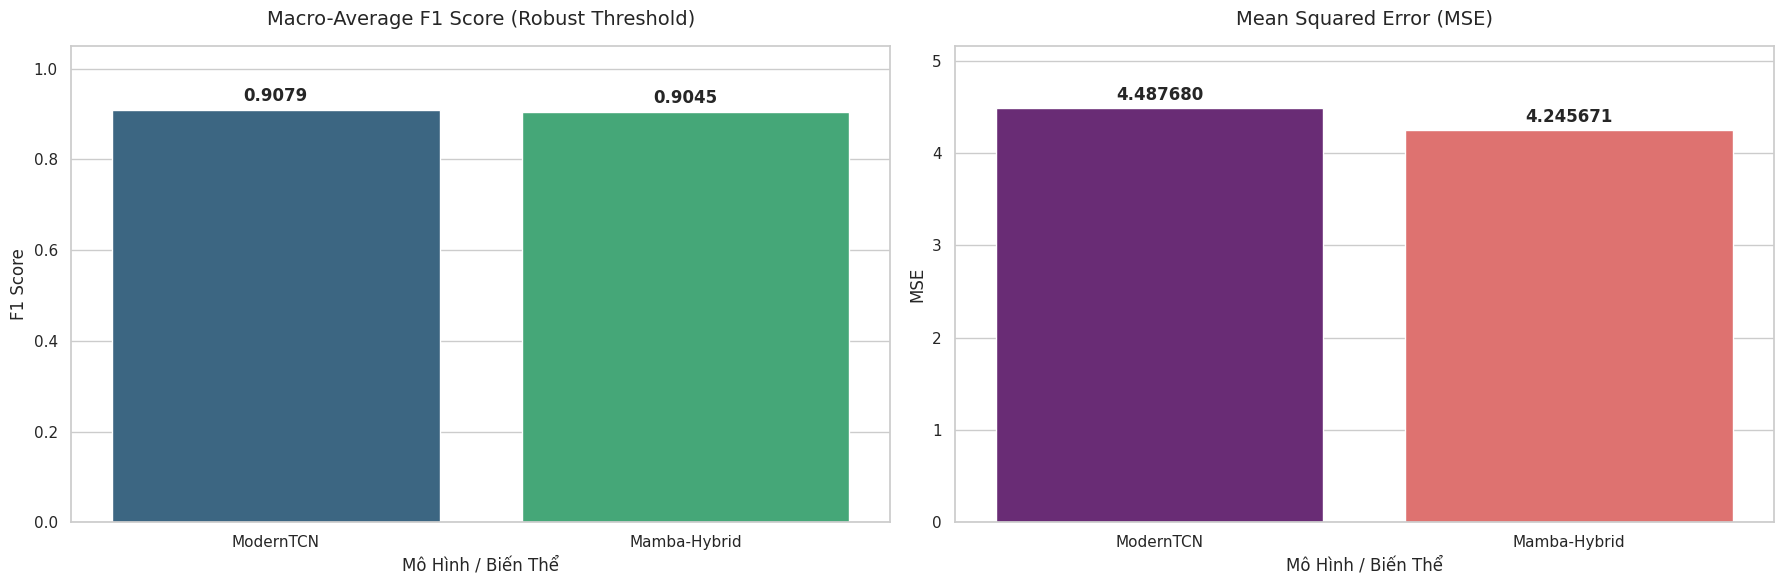

In [21]:
if results:
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    variants = list(results.keys())
    # Rút gọn tên hiển thị
    display_names = [v.replace("Variant_", "V") for v in variants]

    f1_robust = [results[v]["F1 (Robust)"] for v in variants]
    mse_vals = [results[v]["Test MSE"] for v in variants]

    # 1. Biểu đồ cột cho F1 Score
    sns.barplot(x=display_names, y=f1_robust, ax=axes[0], hue=display_names, palette="viridis", legend=False)
    axes[0].set_title("Macro-Average F1 Score (Robust Threshold)", fontsize=14, pad=15)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("F1 Score", fontsize=12)
    axes[0].set_xlabel("Mô Hình / Biến Thể", fontsize=12)
    for i, v in enumerate(f1_robust):
        axes[0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

    # 2. Biểu đồ cột cho MSE
    sns.barplot(x=display_names, y=mse_vals, ax=axes[1], palette="magma")
    axes[1].set_title("Mean Squared Error (MSE)", fontsize=14, pad=15)
    axes[1].set_ylabel("MSE", fontsize=12)
    axes[1].set_xlabel("Mô Hình / Biến Thể", fontsize=12)
    max_mse = max(mse_vals) if len(mse_vals) > 0 else 1.0
    axes[1].set_ylim(0, max_mse * 1.15)
    for i, v in enumerate(mse_vals):
        axes[1].text(i, v + (max_mse * 0.02), f"{v:.6f}", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu để vẽ biểu đồ.")


Tìm thấy các vòng bi để trực quan hóa: ['B01', 'B03', 'B04', 'B08', 'B10', 'B12', 'B17']


Đã lưu biểu đồ: /kaggle/working/results/plots/ablation_proof_B01_fa_md.png


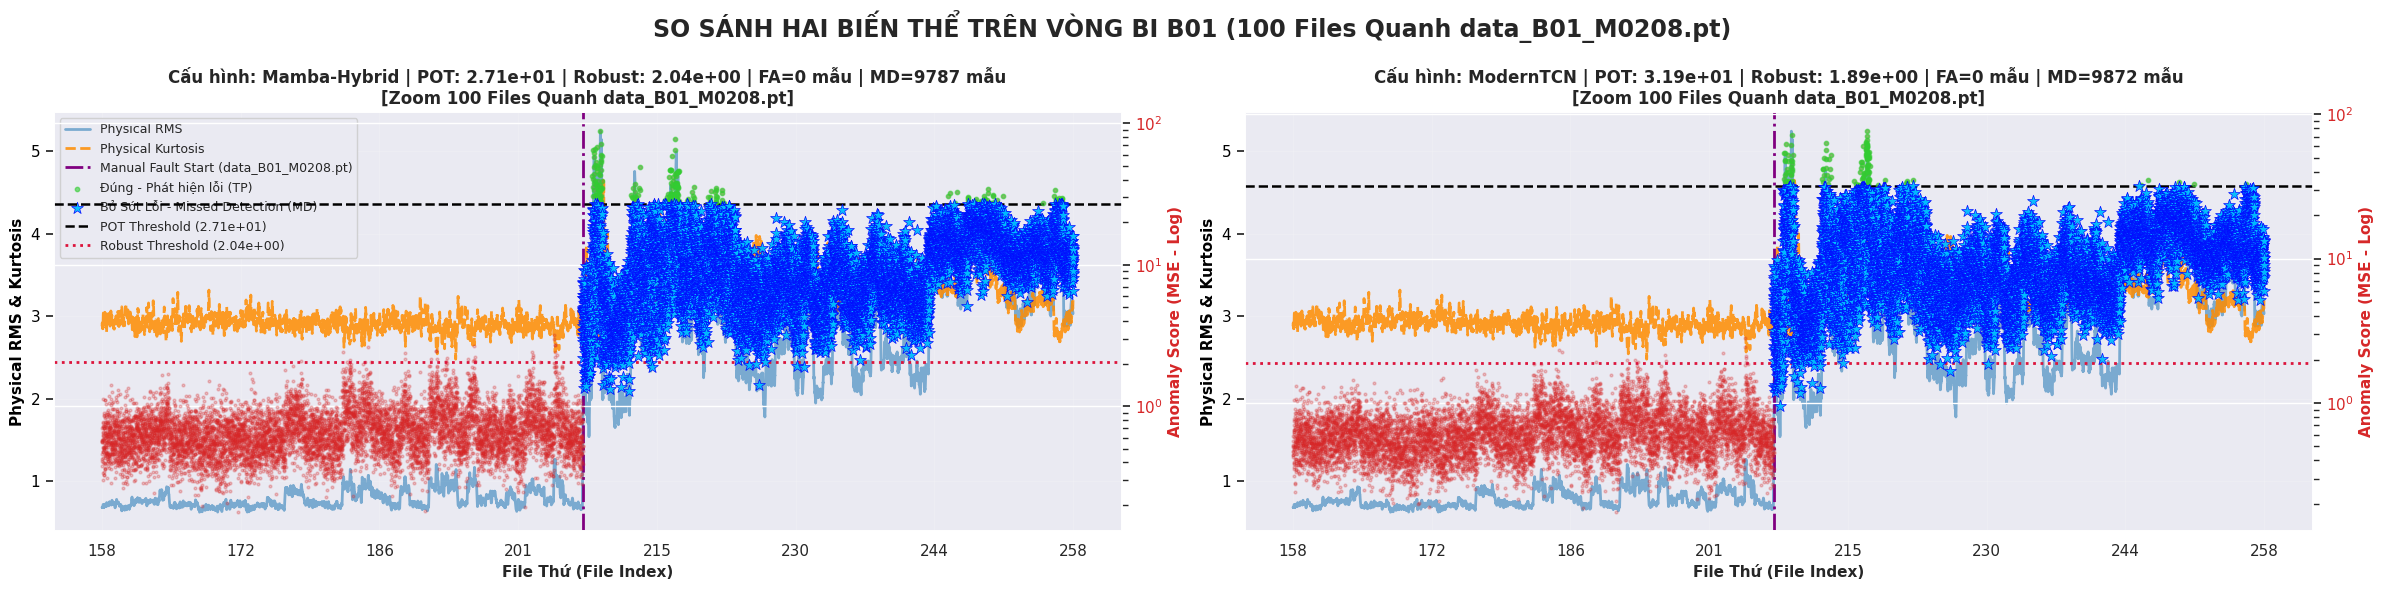

Đã lưu biểu đồ: /kaggle/working/results/plots/ablation_proof_B03_fa_md.png


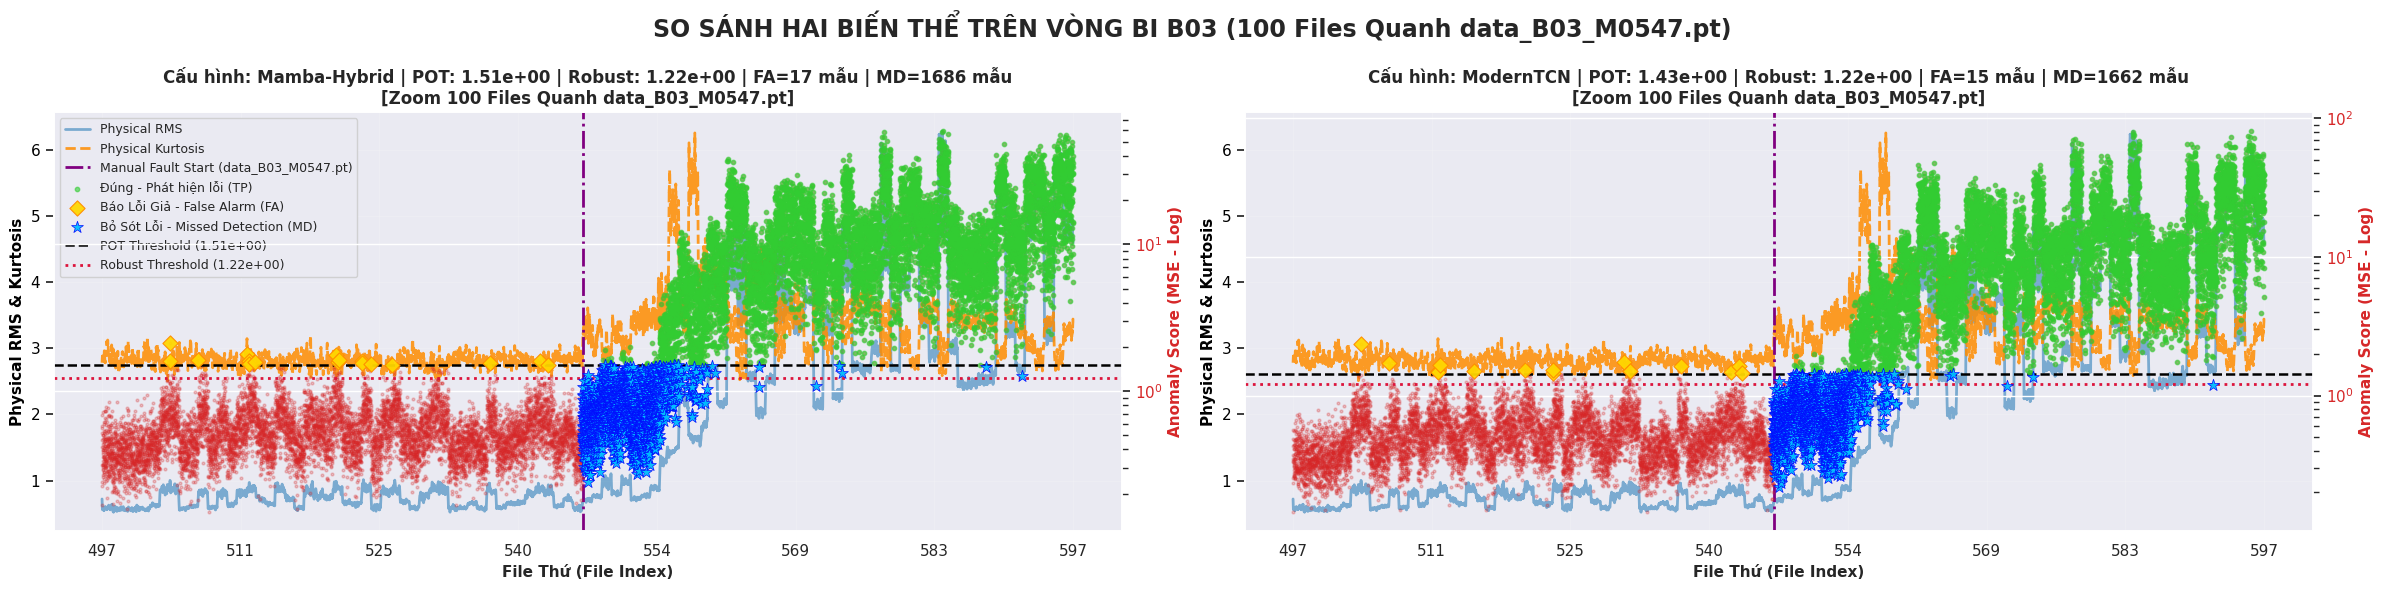

Đã lưu biểu đồ: /kaggle/working/results/plots/ablation_proof_B04_fa_md.png


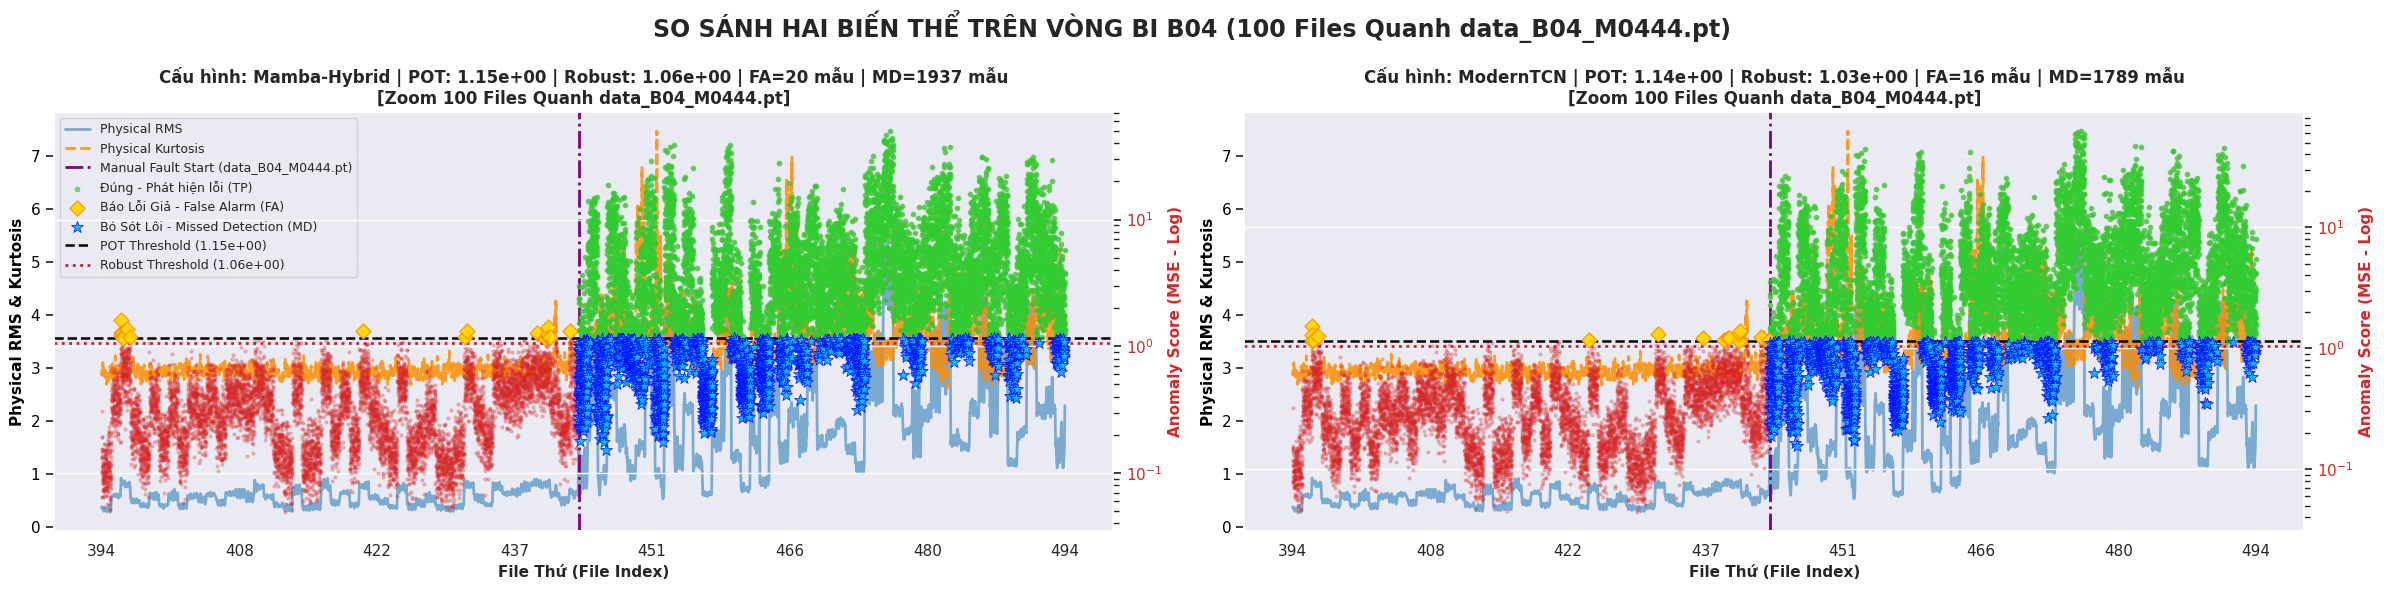

Đã lưu biểu đồ: /kaggle/working/results/plots/ablation_proof_B08_fa_md.png


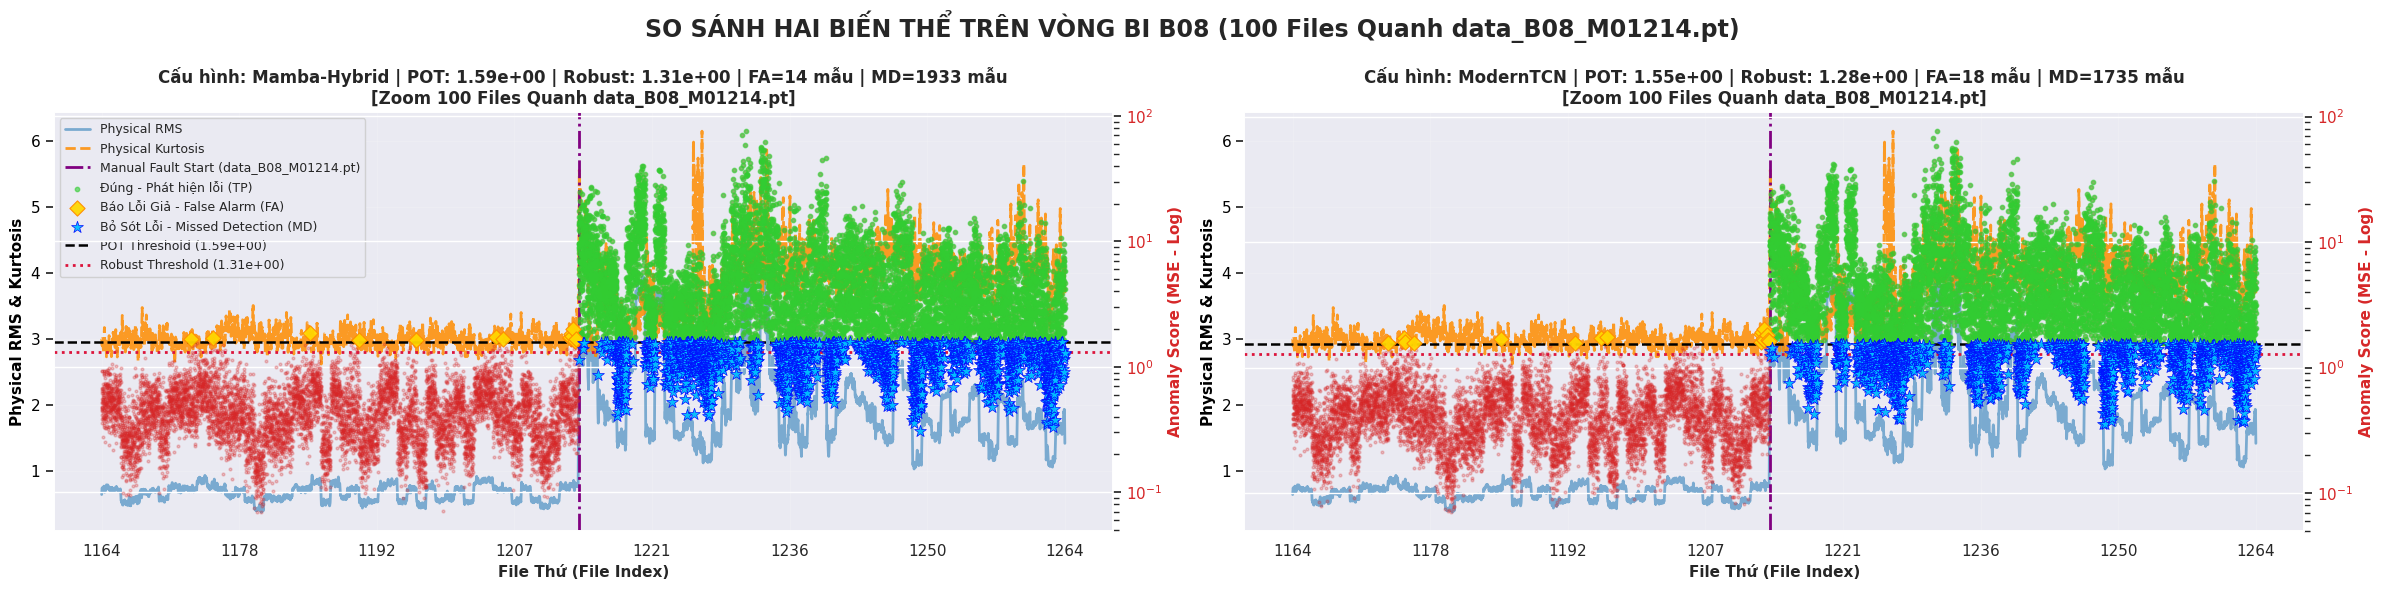

Đã lưu biểu đồ: /kaggle/working/results/plots/ablation_proof_B10_fa_md.png


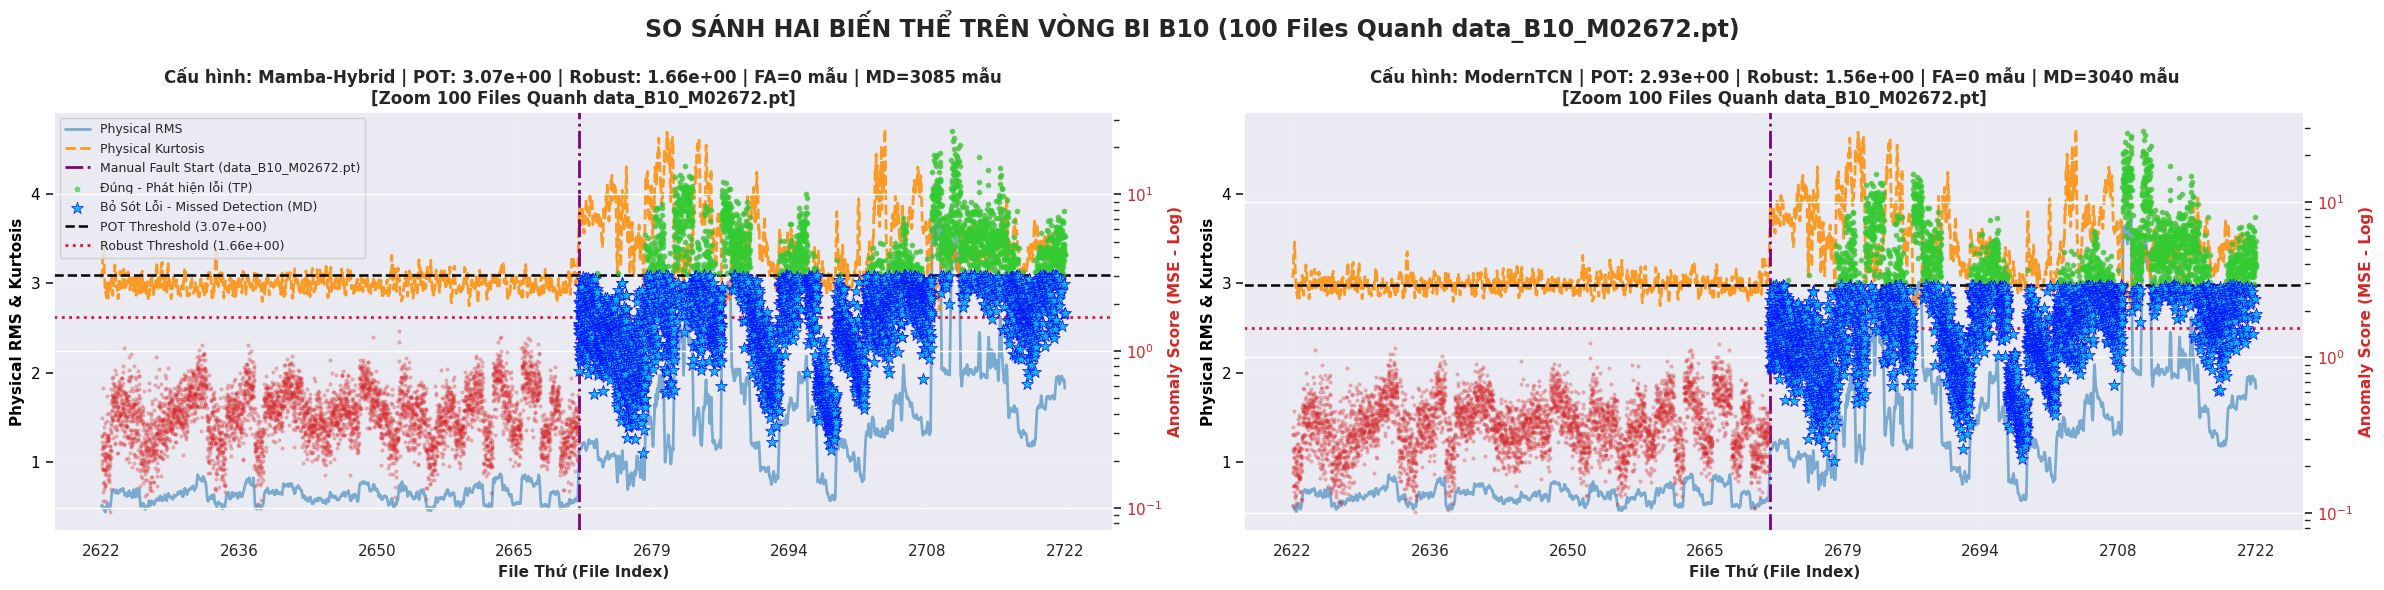

Đã lưu biểu đồ: /kaggle/working/results/plots/ablation_proof_B12_fa_md.png


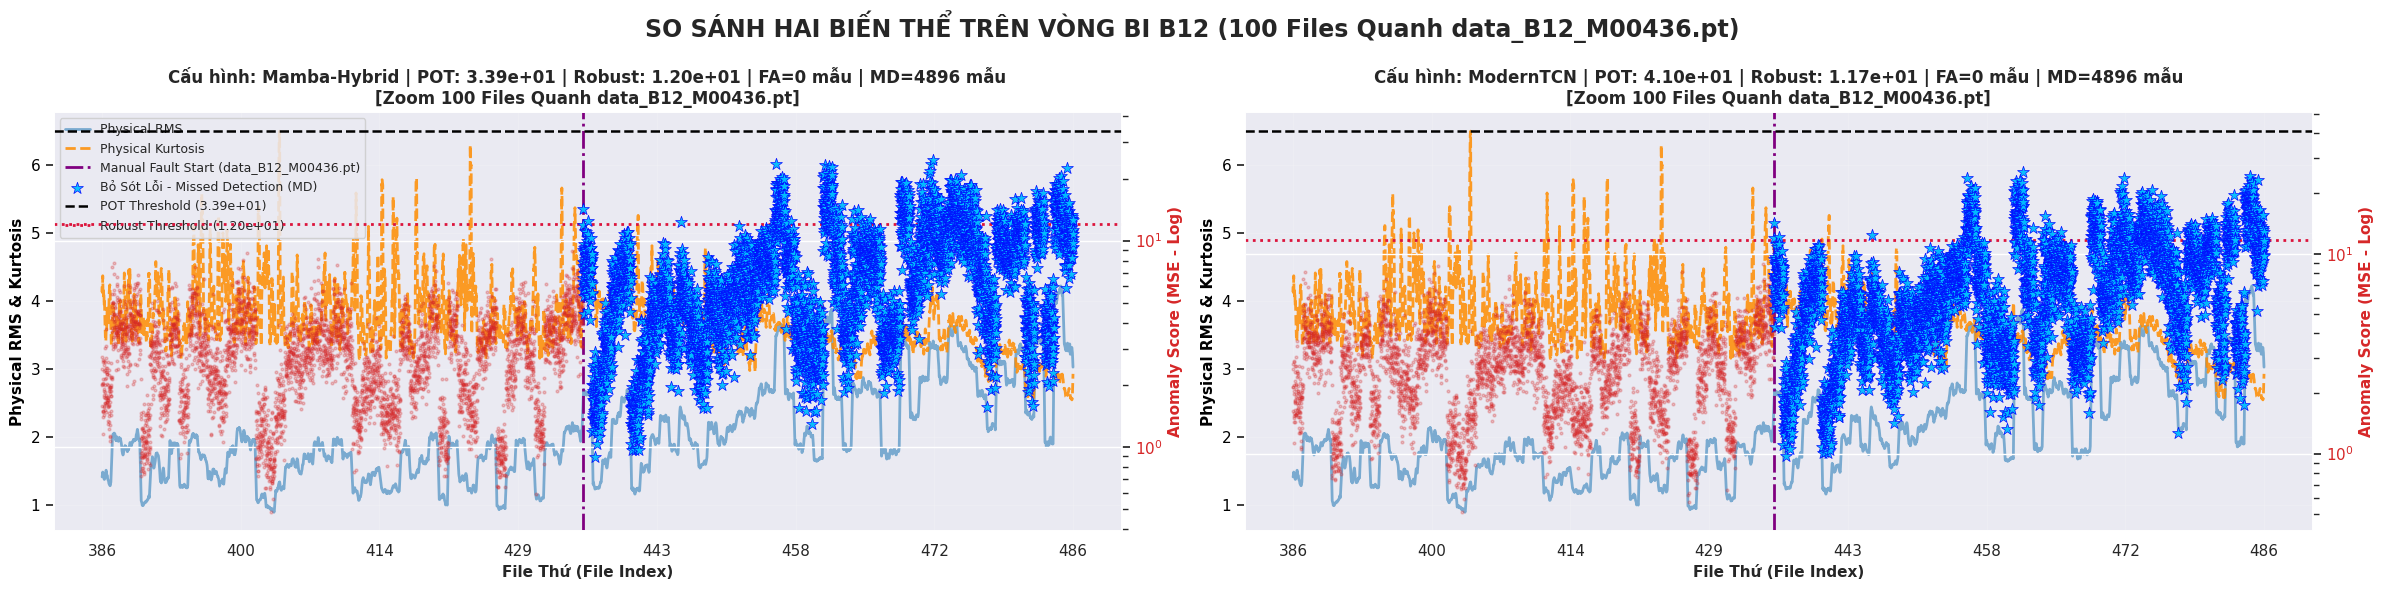

Đã lưu biểu đồ: /kaggle/working/results/plots/ablation_proof_B17_fa_md.png


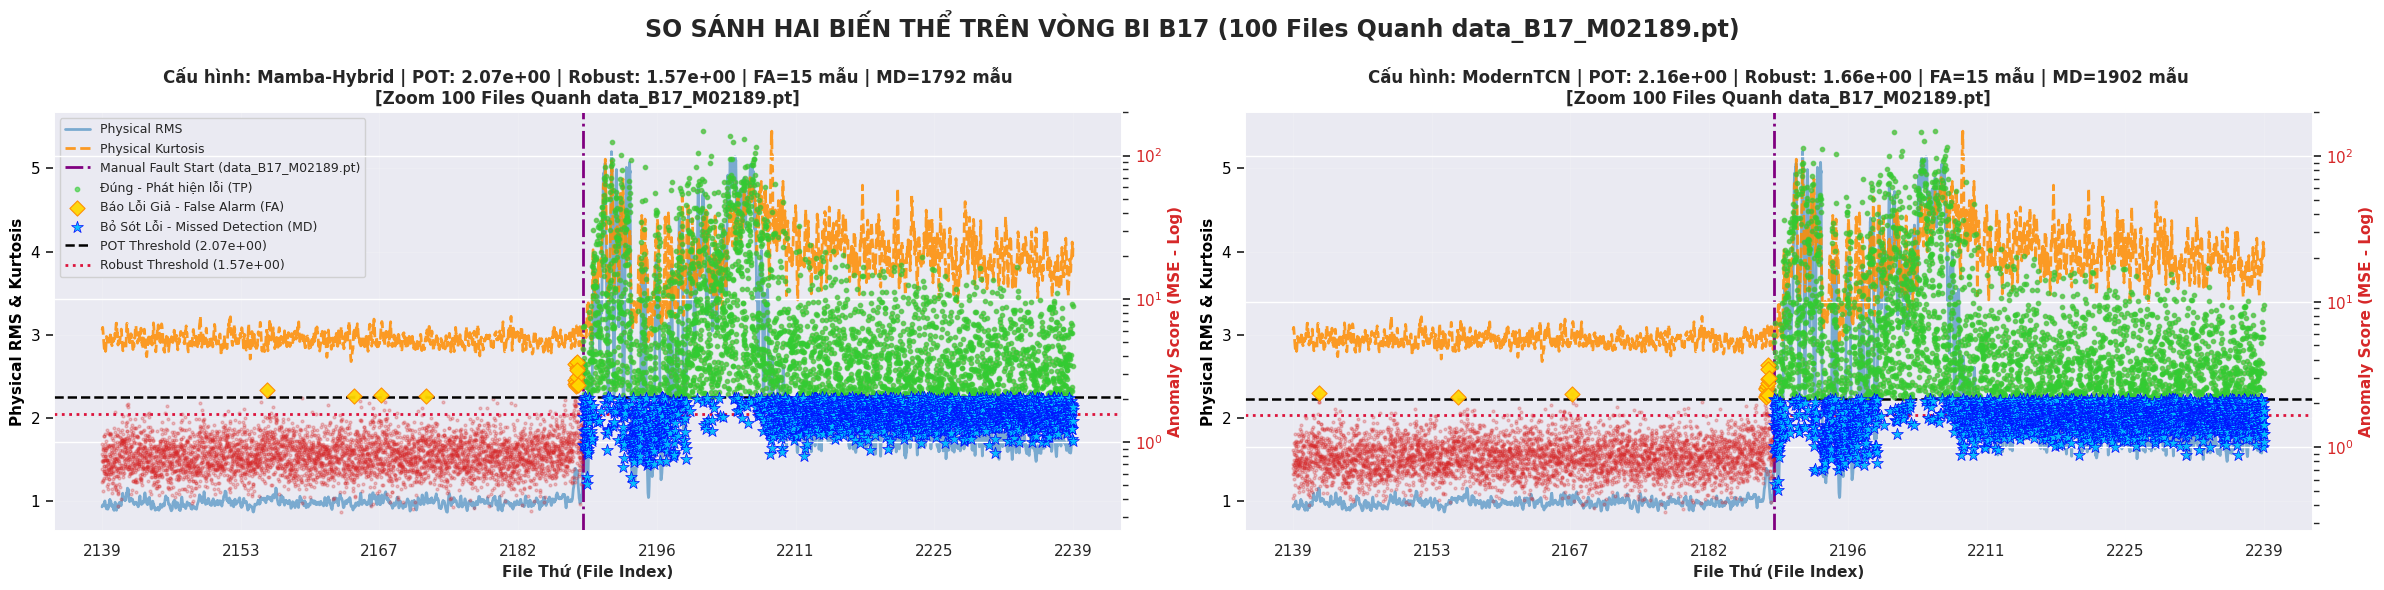

In [22]:
# --- TRỰC QUAN HÓA SO SÁNH TRÊN TỪNG VÒNG BI (Vẽ Dual Y-Axis + Highlight FA/MD) ---
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

if 'is_kaggle' in globals() and is_kaggle:
    plot_save_dir = "/kaggle/working/results/plots"
else:
    plot_save_dir = os.path.join(project_root, "results/plots")

os.makedirs(plot_save_dir, exist_ok=True)

POT_Q = 1e-3

# BIẾN TÙY CHỈNH MỚI: Số lượng file muốn hiển thị quanh điểm bắt đầu lỗi (mặc định 100)
ZOOM_WINDOW_SIZE = 100
half_window = ZOOM_WINDOW_SIZE // 2

# fault_start_files = {
#     "B01": "data_B01_M0208.pt",
#     "B03": "data_B03_M0555.pt"
# }

if 'comparison_results' in globals() and len(comparison_results) > 0:
    bearing_ids = sorted(list(comparison_results.keys()))
    print(f"Tìm thấy các vòng bi để trực quan hóa: {bearing_ids}")

    for b_id in bearing_ids:
        if len(comparison_results[b_id]) == 0:
            continue

        sorted_models = sorted(list(comparison_results[b_id].keys()))
        n_models = len(sorted_models)
        n_cols = 2
        n_rows = (n_models + 1) // 2

        sns.set_theme(style="darkgrid")
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows), sharex=False)

        axes = axes.flatten()

        for idx, cfg_name in enumerate(sorted_models):
            ax = axes[idx]
            res = comparison_results[b_id][cfg_name]

            scores       = np.array(res['mse'])
            file_indices = np.array(res['file_indices'])
            rms_vals    = np.array(res['rms'])
            kurt_vals   = np.array(res['kurtosis'])

            # Smooth RMS & Kurtosis
            rms_vals  = pd.Series(rms_vals).rolling(window=15, min_periods=1, center=True).mean().values
            kurt_vals = pd.Series(kurt_vals).rolling(window=15, min_periods=1, center=True).mean().values

            # POT and Robust thresholds on first 20% healthy
            n_init = max(3, int(len(scores) * 0.2))
            threshold_pot = calculate_threshold_pot(scores[:n_init], q=POT_Q) if len(scores) >= n_init else 1.0
            threshold_robust = calculate_threshold_robust(scores[:n_init], k=3) if len(scores) >= n_init else 1.0

            # Identify manual fault point
            target_file    = manual_fault_start.get(b_id)
            has_manual_fault = (target_file is not None
                                and 'files' in res
                                and target_file in res['files'])

            if has_manual_fault:
                start_idx  = res['files'].index(target_file)
                # Dùng biến tùy chỉnh half_window thay vì fix cứng 25
                min_f_idx  = max(0, start_idx - half_window)
                max_f_idx  = min(len(res['files']) - 1, start_idx + half_window)
                mask       = (file_indices >= min_f_idx) & (file_indices <= max_f_idx)

                scores_sliced     = scores[mask]
                rms_sliced        = rms_vals[mask]
                kurt_sliced       = kurt_vals[mask]
                file_idx_sliced   = file_indices[mask]

                x_vals = np.arange(len(scores_sliced))
                highlight_idx = np.where(file_idx_sliced == start_idx)[0]
                highlight_x   = highlight_idx[0] if len(highlight_idx) > 0 else None

                x_label      = 'File Thứ (File Index)'
                # Cập nhật số lượng hiển thị trên title
                title_suffix = f"\n[Zoom {ZOOM_WINDOW_SIZE} Files Quanh {target_file}]"

                # Build local boolean: before / after fault boundary
                if highlight_x is not None:
                    before_fault = x_vals < highlight_x   # True = trước thời điểm lỗi
                    after_fault  = x_vals >= highlight_x  # True = sau thời điểm lỗi
                else:
                    before_fault = np.ones(len(x_vals), dtype=bool)
                    after_fault  = np.zeros(len(x_vals), dtype=bool)
            else:
                start_slice = int(len(scores) * 0.3)
                scores_sliced   = scores[start_slice:]
                rms_sliced      = rms_vals[start_slice:]
                kurt_sliced     = kurt_vals[start_slice:]
                file_idx_sliced = file_indices[start_slice:]
                x_vals          = np.arange(len(scores_sliced))
                highlight_x     = None
                x_label         = 'Mẫu (Sample)'
                title_suffix    = "\n[Vòng đời 30% - 100%]"
                before_fault    = np.ones(len(x_vals), dtype=bool)
                after_fault     = np.zeros(len(x_vals), dtype=bool)

            # ── LEFT AXIS: RMS & Kurtosis ────────────────────────────────────
            ax.plot(x_vals, rms_sliced,  color='tab:blue',    label='Physical RMS',      linewidth=2.0, alpha=0.55)
            ax.plot(x_vals, kurt_sliced, color='darkorange',  label='Physical Kurtosis', linewidth=2.0, alpha=0.85, linestyle='--')
            ax.set_ylabel('Physical RMS & Kurtosis', color='black', fontsize=11, fontweight='bold')
            ax.tick_params(axis='y', labelcolor='black')

            # ── RIGHT AXIS: Anomaly Score ────────────────────────────────────
            ax_twin = ax.twinx()

            # Classify samples into 4 categories using POT threshold as reference
            above_thresh = scores_sliced > threshold_pot
            below_thresh = ~above_thresh

            # 1. TRUE POSITIVE  — after fault  & above thresh  → correct alarm (green scatter on top)
            tp_mask = after_fault  & above_thresh
            # 2. TRUE NEGATIVE  — before fault & below thresh  → correct healthy (light red, small)
            tn_mask = before_fault & below_thresh
            # 3. FALSE ALARM    — before fault & above thresh  → báo lỗi giả (bright orange/yellow, big)
            fa_mask = before_fault & above_thresh
            # 4. MISSED DETECT  — after fault  & below thresh  → báo ổn định giả (bright blue, big)
            md_mask = after_fault  & below_thresh

            # Base line: all points faint red
            ax_twin.scatter(x_vals, scores_sliced, color='tab:red', s=4, alpha=0.25, zorder=2)

            # TP: correct alarms — lime green dots
            if tp_mask.any():
                ax_twin.scatter(x_vals[tp_mask], scores_sliced[tp_mask],
                                color='limegreen', s=10, alpha=0.6, zorder=3,
                                label='Đúng - Phát hiện lỗi (TP)')

            # TN: correct healthy — light blue-grey (already covered by base, no extra scatter needed)

            # FA: False Alarm — vivid orange diamond, large
            if fa_mask.any():
                ax_twin.scatter(x_vals[fa_mask], scores_sliced[fa_mask],
                                color='gold', marker='D', s=60, alpha=0.95,
                                edgecolors='darkorange', linewidths=0.8, zorder=5,
                                label='Báo Lỗi Giả - False Alarm (FA)')

            # MD: Missed Detection — vivid cyan star, large
            if md_mask.any():
                ax_twin.scatter(x_vals[md_mask], scores_sliced[md_mask],
                                color='deepskyblue', marker='*', s=80, alpha=0.95,
                                edgecolors='blue', linewidths=0.5, zorder=5,
                                label='Bỏ Sót Lỗi - Missed Detection (MD)')

            # POT threshold line
            ax_twin.axhline(y=threshold_pot, color='black', linestyle='--', linewidth=1.8,
                            label=f'POT Threshold ({threshold_pot:.2e})')

            # Robust threshold line
            ax_twin.axhline(y=threshold_robust, color='crimson', linestyle=':', linewidth=2.0,
                            label=f'Robust Threshold ({threshold_robust:.2e})')

            # Fault boundary line
            if highlight_x is not None:
                ax.axvline(x=highlight_x, color='purple', linestyle='-.', linewidth=2.0,
                           label=f'Manual Fault Start ({target_file})')

            ax_twin.set_ylabel('Anomaly Score (MSE - Log)', color='tab:red', fontsize=11, fontweight='bold')
            ax_twin.tick_params(axis='y', labelcolor='tab:red')
            ax_twin.set_yscale('log')

            ax.grid(True, which="both", ls="-", alpha=0.15)

            # X-tick labels → file numbers
            if len(x_vals) > 1:
                tick_indices = np.linspace(0, len(x_vals) - 1, num=8, dtype=int)
                if has_manual_fault:
                    tick_labels = [f"{int(file_idx_sliced[i] + 1)}" for i in tick_indices]
                else:
                    pct = (np.arange(len(scores))[start_slice:] / max(np.arange(len(scores)))) * 100
                    tick_labels = [f"{pct[i]:.1f}%" for i in tick_indices]
                    x_label = 'Vị trí Vòng đời (%) | Life-cycle (%)'
                ax.set_xticks(tick_indices)
                ax.set_xticklabels(tick_labels)

            ax.set_xlabel(x_label, fontsize=11, fontweight='bold')

            # Count FA/MD for title annotation
            n_fa = int(fa_mask.sum())
            n_md = int(md_mask.sum())
            ax.set_title(
                f"Cấu hình: {cfg_name} | POT: {threshold_pot:.2e} | Robust: {threshold_robust:.2e} | FA={n_fa} mẫu | MD={n_md} mẫu{title_suffix}",
                fontsize=12, fontweight='bold'
            )

            # Combined legend (only on first subplot to save space)
            if idx == 0:
                lines1, labels1 = ax.get_legend_handles_labels()
                lines2, labels2 = ax_twin.get_legend_handles_labels()
                ax.legend(lines1 + lines2, labels1 + labels2,
                          loc='upper left', fontsize=9, framealpha=0.85)

        # Hide unused axes
        for unused_idx in range(n_models, len(axes)):
            fig.delaxes(axes[unused_idx])

        num_vi = {1:'MỘT', 2:'HAI', 3:'BA', 4:'BỐN', 5:'NĂM', 6:'SÁU'}
        num_word = num_vi.get(n_models, 'CÁC')

        main_title = f"SO SÁNH {num_word} BIẾN THỂ TRÊN VÒNG BI {b_id}"
        # Cập nhật số lượng trên main title
        main_title += f" ({ZOOM_WINDOW_SIZE} Files Quanh {target_file})" if has_manual_fault else " (Full Life-cycle)"
        fig.suptitle(main_title, fontsize=17, fontweight='bold', y=0.98)
        plt.tight_layout()

        save_path = os.path.join(plot_save_dir, f"ablation_proof_{b_id}_fa_md.png")
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Đã lưu biểu đồ: {save_path}")
        plt.show()
else:
    print("Không tìm thấy comparison_results. Hãy chạy lại phần đánh giá mô hình.")